Importing the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV,cross_val_score

Loading the Dataset

In [2]:
df = pd.read_csv(r"C:\Learning\Week-01(Python & OOP)\Learning-Curve\Week-2\Day-4\winequality-red.csv")

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Exploratory Data Analysis EDA

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.quality.value_counts()# Checking for class imbalance in the target variable

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [7]:
df.columns[:-1]# Separating features and target variable

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')

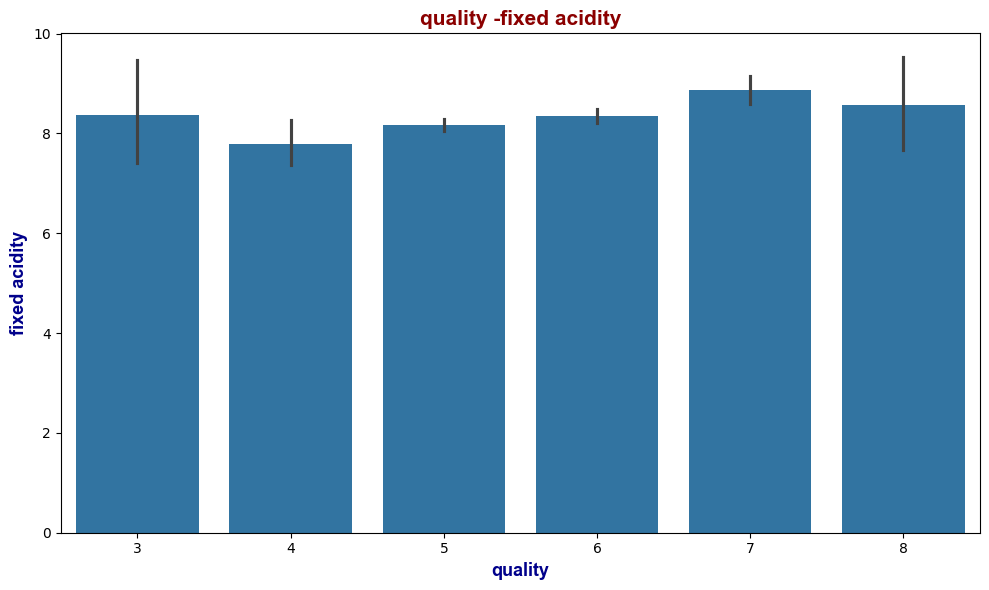

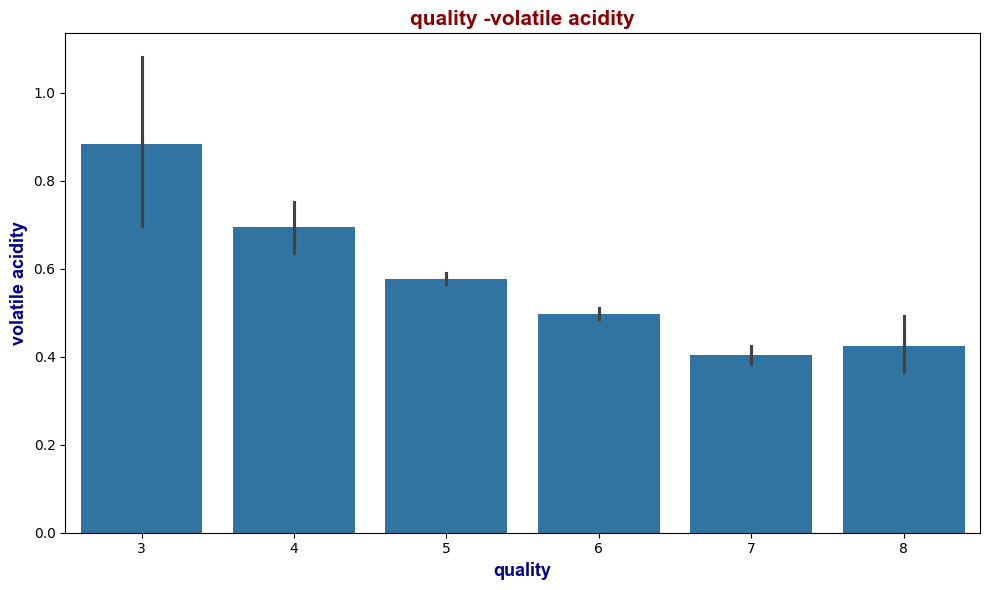

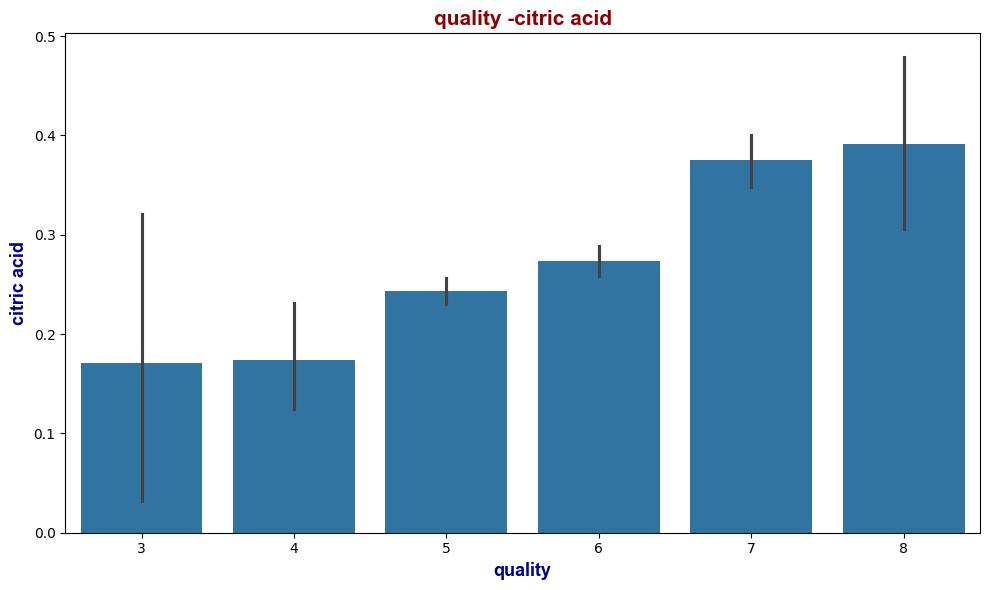

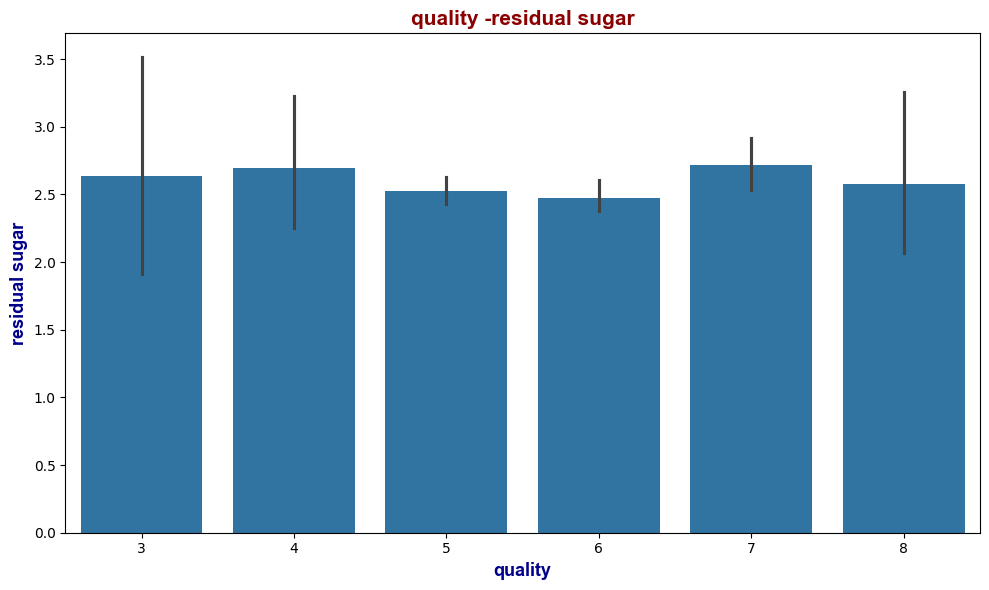

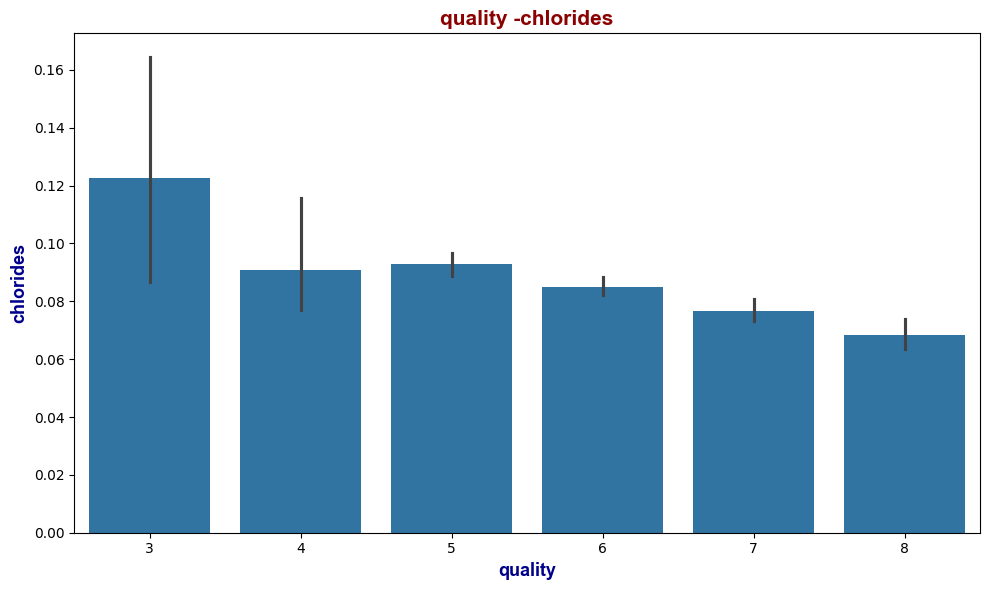

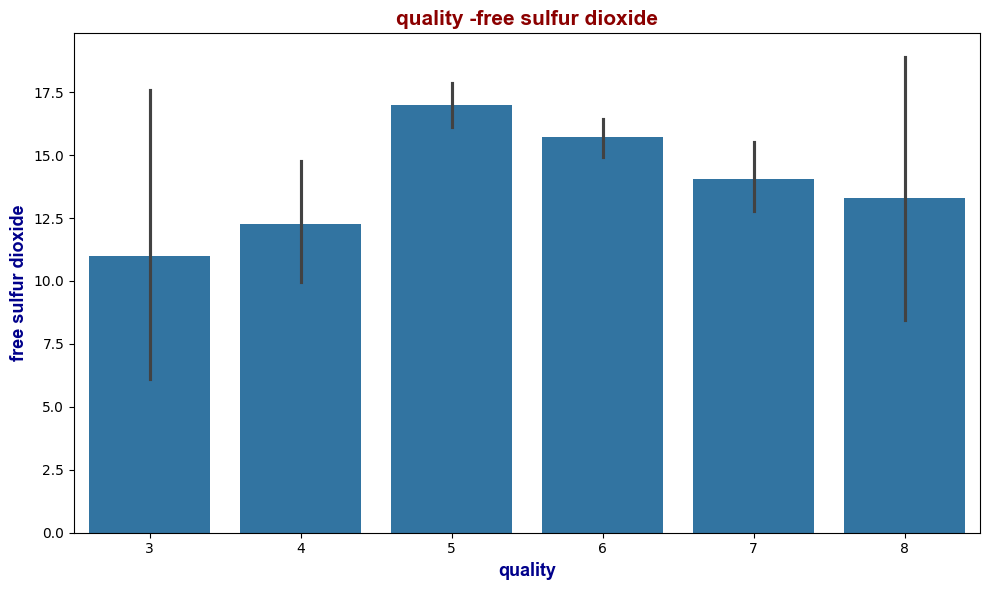

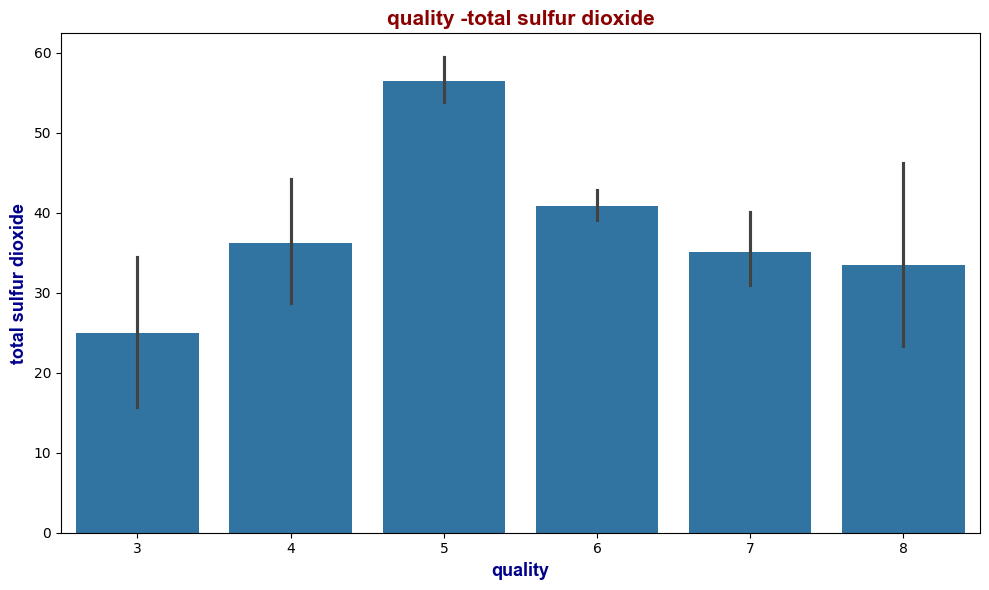

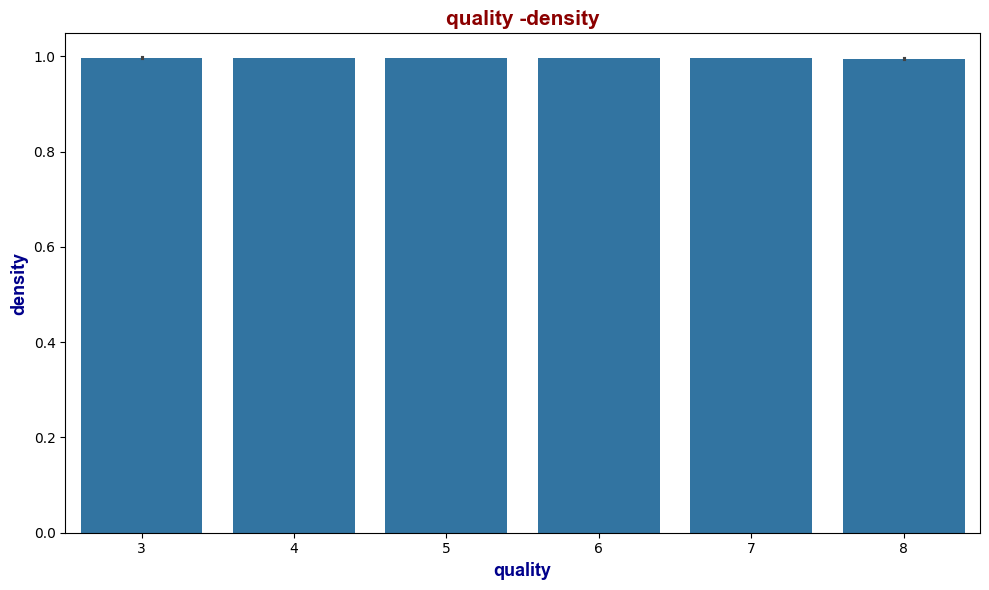

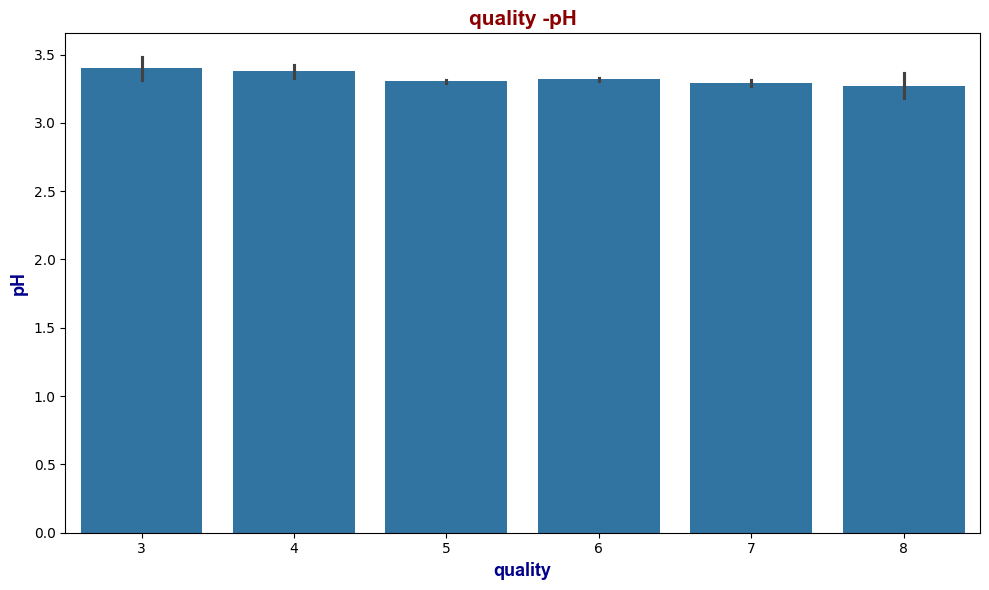

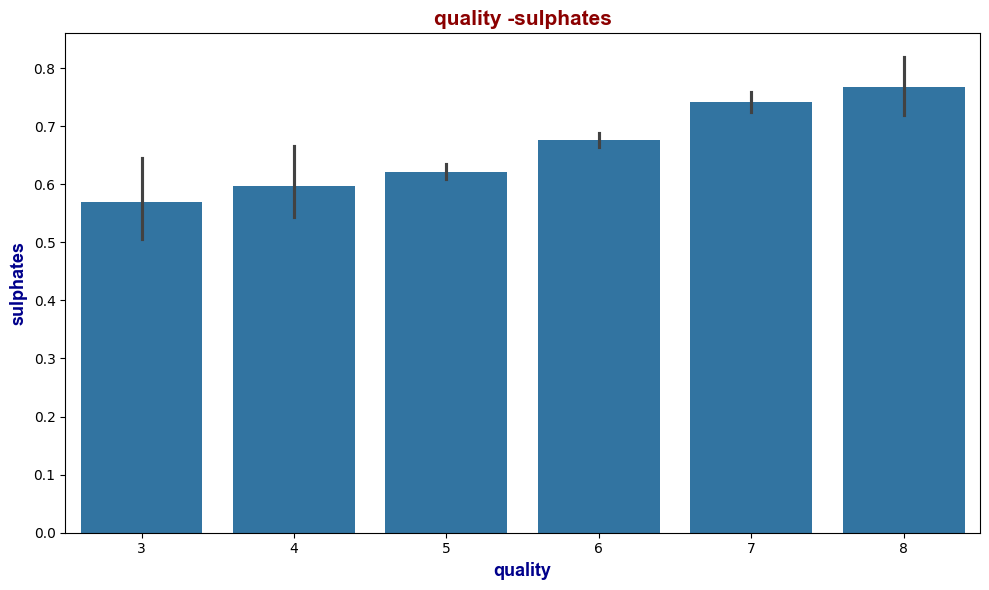

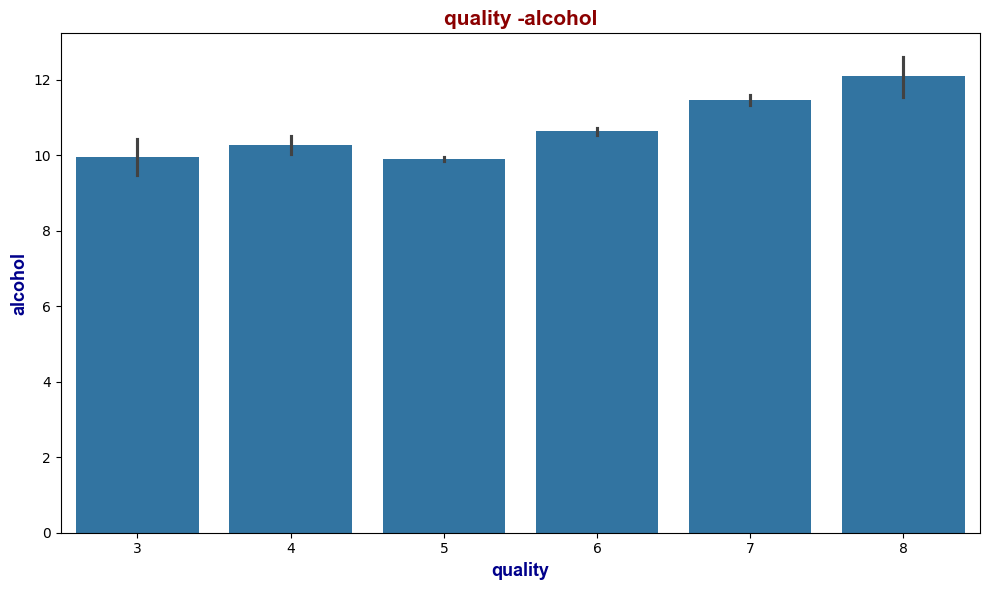

In [10]:
title_font={"family":"arial","color":"darkred","weight":"bold","size":15}
axis_font={"family":"arial","color":"darkblue","weight":"bold","size":13}

for i in df.columns[:-1]:
    plt.figure(figsize=(10,6))
    sns.barplot(x=df.quality, y=df[i], data=df)

    plt.title("quality -" +i, fontdict=title_font)
    plt.xlabel("quality", fontdict=axis_font)
    plt.ylabel(i, fontdict=axis_font)

    plt.tight_layout()
    plt.show()

<Axes: >

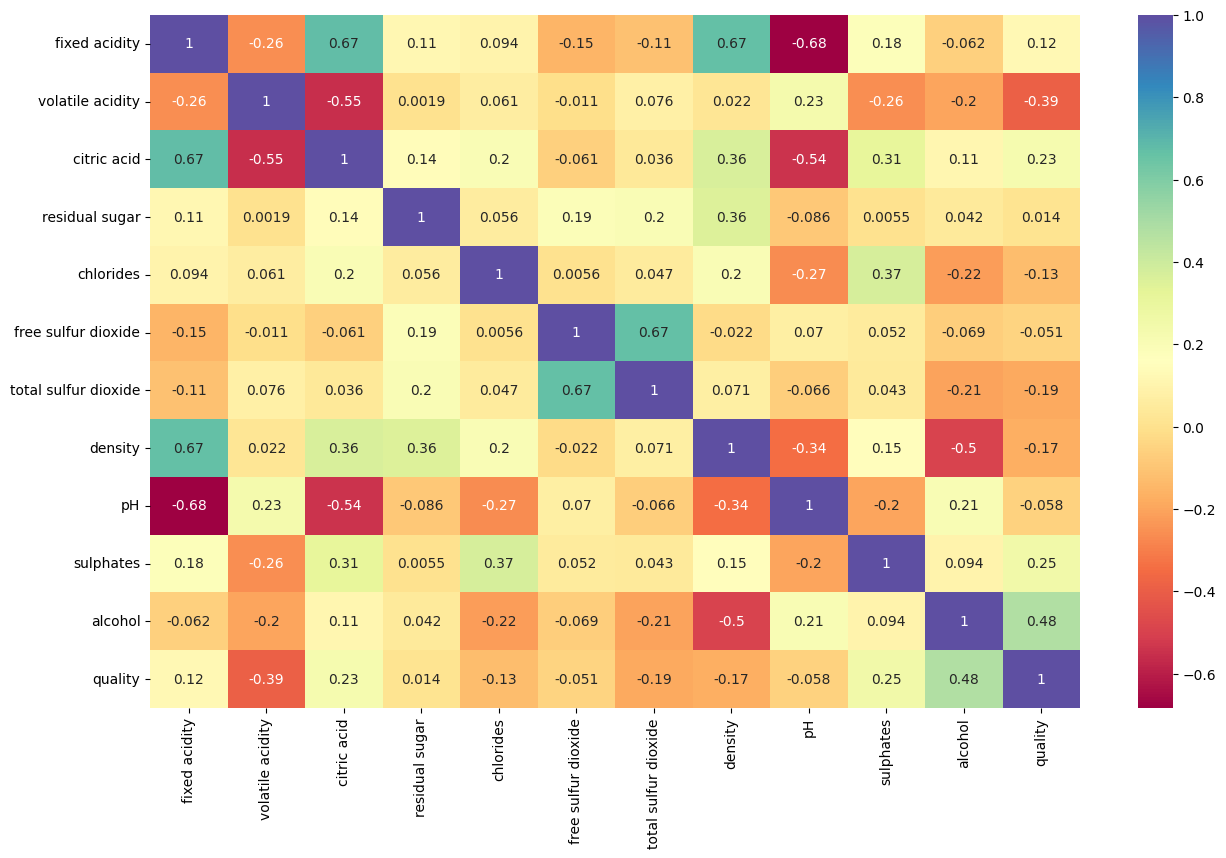

In [11]:
plt.figure(figsize=(15,9))
sns.heatmap(df.corr(), annot=True, cmap="Spectral")

Preparation for modelling

In [12]:
df.drop(["residual sugar", "free sulfur dioxide","pH"], axis=1, inplace=True)# Dropping less important features based on correlation analysis

In [13]:
df.head()

,fixed acidity,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,sulphates,alcohol,quality
0,7.4,0.70,0.00,0.076,34.0,0.9978,0.56,9.4,5
1,7.8,0.88,0.00,0.098,67.0,0.9968,0.68,9.8,5
2,7.8,0.76,0.04,0.092,54.0,0.9970,0.65,9.8,5
3,11.2,0.28,0.56,0.075,60.0,0.9980,0.58,9.8,6
4,7.4,0.70,0.00,0.076,34.0,0.9978,0.56,9.4,5


In [14]:
bins=(2,6.5,8)
group_names=["bad","good"]
df.quality=pd.cut(df.quality, bins=bins, labels=group_names)

In [15]:
df.head()

,fixed acidity,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,sulphates,alcohol,quality
0,7.4,0.70,0.00,0.076,34.0,0.9978,0.56,9.4,bad
1,7.8,0.88,0.00,0.098,67.0,0.9968,0.68,9.8,bad
2,7.8,0.76,0.04,0.092,54.0,0.9970,0.65,9.8,bad
3,11.2,0.28,0.56,0.075,60.0,0.9980,0.58,9.8,bad
4,7.4,0.70,0.00,0.076,34.0,0.9978,0.56,9.4,bad


<Axes: xlabel='quality', ylabel='count'>

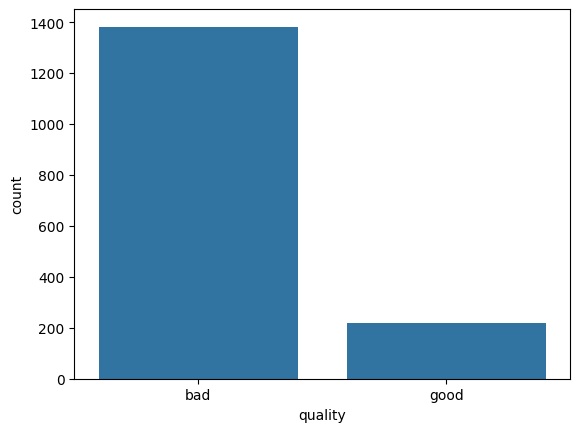

In [16]:
sns.countplot(x=df.quality, data=df)

In [ ]:
from sklearn.preprocessing import LabelEncoder
new_quality=LabelEncoder()
df.quality=new_quality.fit_transform(df.quality)# Encoding target variable and checking for class imbalance after encoding

In [19]:
df.head()

,fixed acidity,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,sulphates,alcohol,quality
0,7.4,0.70,0.00,0.076,34.0,0.9978,0.56,9.4,0
1,7.8,0.88,0.00,0.098,67.0,0.9968,0.68,9.8,0
2,7.8,0.76,0.04,0.092,54.0,0.9970,0.65,9.8,0
3,11.2,0.28,0.56,0.075,60.0,0.9980,0.58,9.8,0
4,7.4,0.70,0.00,0.076,34.0,0.9978,0.56,9.4,0


In [20]:
df.quality.value_counts()

quality
0    1382
1     217
Name: count, dtype: int64

Modelling the Data

In [21]:
X=df.drop("quality", axis=1)
y=df.quality

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [23]:
##Scaling the features using StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

SVC Modelling(Support Vector Classifier)

In [26]:
from sklearn.svm import SVC
svc_model=SVC()
svc_model.fit(X_train_scaled, y_train)
y_pred=svc_model.predict(X_test_scaled)

In [27]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.875


In [28]:
cv_scores=cross_val_score(svc_model, X_train_scaled, y_train, cv=10)
cv_scores.mean()

np.float64(0.8897699311023622)

Text(70.72222222222221, 0.5, 'Actual')

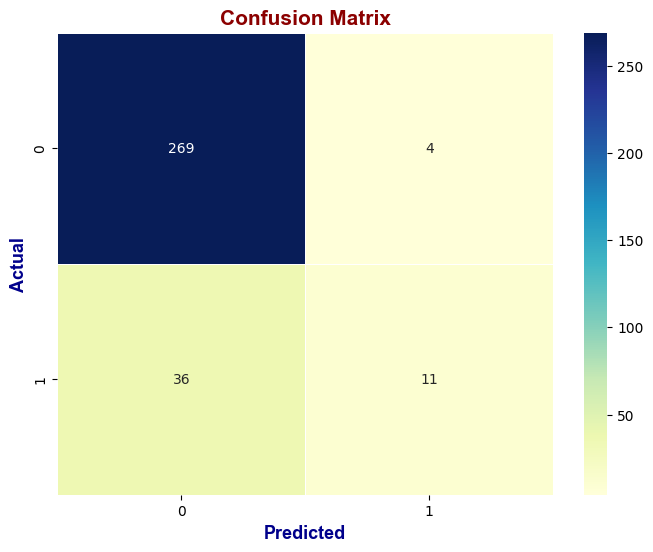

In [34]:
cnf_matrix=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cnf_matrix, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)# Plotting confusion matrix using heatmap,fmt is set to "d" to display integer values in the cells
plt.title("Confusion Matrix", fontdict=title_font)
plt.xlabel("Predicted", fontdict=axis_font)
plt.ylabel("Actual", fontdict=axis_font)

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       273
           1       0.73      0.23      0.35        47

    accuracy                           0.88       320
   macro avg       0.81      0.61      0.64       320
weighted avg       0.86      0.88      0.85       320



Hyperparameter Optimization

In [36]:
svcmodel2=SVC()

In [ ]:
param_grid={"C":[0.1,1,10], "gamma":[1,0.1,0.01], "kernel":["poly","rbf"]}# Defining a parameter grid for hyperparameter tuning

In [ ]:
svc_cv_model=GridSearchCV(estimator=svcmodel2,param_grid=param_grid, cv=10)# Setting up GridSearchCV with the SVC model and the defined parameter grid

In [41]:
svc_cv_model.fit(X_train_scaled, y_train)# Fitting the GridSearchCV model to the training data to find the best hyperparameters

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['poly', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [42]:
svc_cv_model.best_params_# Displaying the best hyperparameters found by GridSearchCV

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}

In [43]:
svc_tuned=SVC(C=1, gamma=1, kernel="rbf")# Creating a new SVC model with the best hyperparameters
svc_tuned.fit(X_train_scaled, y_train)
y_pred_tuned=svc_tuned.predict(X_test_scaled)

In [45]:
print("Accuracy Score:", accuracy_score(y_test, y_pred_tuned))

Accuracy Score: 0.896875


Text(50.722222222222214, 0.5, 'Actual')

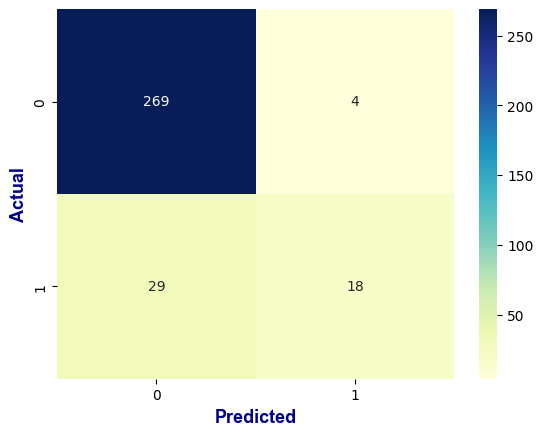

In [47]:
cnf_matrix_tuned=confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cnf_matrix_tuned, annot=True, fmt="d", cmap="YlGnBu")
plt.xlabel("Predicted", fontdict=axis_font)
plt.ylabel("Actual", fontdict=axis_font)